In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add src to path (this allows us to import from the src folder)
sys.path.append(os.path.abspath('..'))

# Import ALL functions from data_processing.py
from src.data_processing import (
    # Data fetching
    fetch_stock_data,
    combine_prices,
    get_data_summary,
    verify_data_types,
    
    # Data cleaning
    clean_data,
    check_missing,
    calculate_returns,
    
    # Visualization
    plot_prices,
    plot_returns,
    plot_rolling_volatility,
    plot_correlation_heatmap,
    plot_returns_distribution,
    
    # Statistical tests
    test_stationarity,
    analyze_all_stationarity,
    
    # Risk metrics
    calculate_risk_metrics,
    calculate_all_risk_metrics,
    detect_outliers,
    detect_all_outliers,
    analyze_extreme_days,
    
    # Reporting
    generate_summary_report
)

# Settings
pd.set_option('display.float_format', lambda x: '%.4f' % x)

### Fetch Data

In [2]:
TICKERS = ['TSLA', 'BND', 'SPY']
START = '2015-01-01'
END = '2026-06-30'

# Fetch raw data
raw_data = fetch_stock_data(TICKERS, START, END)# Show summary
summary = get_data_summary(raw_data)
print("\n Data Summary:")
display(summary)

Fetching data for ['TSLA', 'BND', 'SPY']...
----------------------------------------
  TSLA: 2,888 rows
  BND: 2,888 rows
  SPY: 2,888 rows
----------------------------------------
Data fetching complete!

 Data Summary:


,Ticker,Start,End,Rows,Columns
0,TSLA,2015-01-02,2026-06-29,2888,8
1,BND,2015-01-02,2026-06-29,2888,9
2,SPY,2015-01-02,2026-06-29,2888,9


In [3]:
# Show sample data
for ticker in TICKERS:
    print(f"\n {ticker} - First 5 rows:")
    display(raw_data[ticker].head())


 TSLA - First 5 rows:


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2015-01-02 00:00:00-05:00,14.8580,14.8833,14.2173,14.6207,14.6207,71466000,0.0000,0.0000
2015-01-05 00:00:00-05:00,14.3033,14.4333,13.8107,14.0060,14.0060,80527500,0.0000,0.0000
2015-01-06 00:00:00-05:00,14.0040,14.2800,13.6140,14.0853,14.0853,93928500,0.0000,0.0000
2015-01-07 00:00:00-05:00,14.2233,14.3187,13.9853,14.0633,14.0633,44526000,0.0000,0.0000
2015-01-08 00:00:00-05:00,14.1873,14.2533,14.0007,14.0413,14.0413,51637500,0.0000,0.0000



 BND - First 5 rows:


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2015-01-02 00:00:00-05:00,82.4300,82.6900,82.4200,82.6500,59.2057,2218800,0.0000,0.0000,0.0000
2015-01-05 00:00:00-05:00,82.7400,82.9200,82.7000,82.8900,59.3776,5820100,0.0000,0.0000,0.0000
2015-01-06 00:00:00-05:00,83.0300,83.3800,83.0300,83.1300,59.5495,3887600,0.0000,0.0000,0.0000
2015-01-07 00:00:00-05:00,83.1400,83.2800,83.0500,83.1800,59.5853,2433400,0.0000,0.0000,0.0000
2015-01-08 00:00:00-05:00,83.1100,83.1100,82.9700,83.0500,59.4922,1873400,0.0000,0.0000,0.0000



 SPY - First 5 rows:


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2015-01-02 00:00:00-05:00,206.3800,206.8800,204.1800,205.4300,169.6878,121465900,0.0000,0.0000,0.0000
2015-01-05 00:00:00-05:00,204.1700,204.3700,201.3500,201.7200,166.6234,169632600,0.0000,0.0000,0.0000
2015-01-06 00:00:00-05:00,202.0900,202.7200,198.8600,199.8200,165.0539,209151400,0.0000,0.0000,0.0000
2015-01-07 00:00:00-05:00,201.4200,202.7200,200.8800,202.3100,167.1107,125346700,0.0000,0.0000,0.0000
2015-01-08 00:00:00-05:00,204.0100,206.1600,203.9900,205.9000,170.0761,147217800,0.0000,0.0000,0.0000


### DATA CLEANING AND UNDERSTANDING

In [5]:
# 3.1 Check for missing values
print("\n Checking for missing values:")
check_missing(raw_data)

# 3.2 Verify data types
print("\nVerifying data types:")
type_summary = verify_data_types(raw_data)
display(type_summary)



 Checking for missing values:

Checking for missing values...
----------------------------------------
  TSLA: No missing values
  BND: No missing values
  SPY: No missing values

Verifying data types:

DATA TYPE VERIFICATION

 TSLA:
------------------------------
  Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
  Index is DatetimeIndex: True
  Open: float64
    Open is numeric
  High: float64
    High is numeric
  Low: float64
    Low is numeric
  Close: float64
    Close is numeric
  Adj Close: float64
    Adj Close is numeric
  Volume: int64
    Volume is numeric
  Dividends: float64
    Dividends is numeric
  Stock Splits: float64
    Stock Splits is numeric

 BND:
------------------------------
  Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
  Index is DatetimeIndex: True
  Open: float64
    Open is numeric
  High: float64
    High is numeric
  Low: float64
    Low is numeric
  Close: float64
    Close is numeric
  Adj Close: float64
    Adj

,Ticker,Index_Type,Columns,Data_Types
0,TSLA,<class 'pandas.core.indexes.datetimes.Datetime...,"Open, High, Low, Close, Adj Close, Volume, Div...","Open: float64, High: float64, Low: float64, Cl..."
1,BND,<class 'pandas.core.indexes.datetimes.Datetime...,"Open, High, Low, Close, Adj Close, Volume, Div...","Open: float64, High: float64, Low: float64, Cl..."
2,SPY,<class 'pandas.core.indexes.datetimes.Datetime...,"Open, High, Low, Close, Adj Close, Volume, Div...","Open: float64, High: float64, Low: float64, Cl..."


In [6]:
# 3.3 Clean the data
print("\n Cleaning data:")
cleaned_data = clean_data(raw_data, method='ffill')

# 3.4 Verify cleaning worked
print("\nVerifying cleaning:")
check_missing(cleaned_data)


 Cleaning data:

 Cleaning data using method: ffill
----------------------------------------
    TSLA: Cleaned (no missing values)
    BND: Cleaned (no missing values)
    SPY: Cleaned (no missing values)

Verifying cleaning:

Checking for missing values...
----------------------------------------
  TSLA: No missing values
  BND: No missing values
  SPY: No missing values


#### Basic statistics

In [7]:
print("\n Basic Statistics - TSLA:")
display(cleaned_data['TSLA'].describe())

print("\n Basic Statistics - BND:")
display(cleaned_data['BND'].describe())

print("\n Basic Statistics - SPY:")
display(cleaned_data['SPY'].describe())


 Basic Statistics - TSLA:


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000
mean,148.7973,151.9906,145.4167,148.7739,148.7739,108792194.4598,0.0000,0.0028
std,138.9772,141.8528,135.8672,138.8960,138.8960,70825493.1529,0.0000,0.1085
min,9.4880,10.3313,9.4033,9.5780,9.5780,10620000.0000,0.0000,0.0000
25%,18.3908,18.6652,18.0237,18.3935,18.3935,65483250.0000,0.0000,0.0000
50%,131.4963,136.0533,125.8317,133.4377,133.4377,90336150.0000,0.0000,0.0000
75%,251.6800,257.4850,245.8325,251.9258,251.9258,126120450.0000,0.0000,0.0000
max,489.8800,498.8300,485.3300,489.8800,489.8800,914082000.0000,0.0000,5.0000



 Basic Statistics - BND:


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000
mean,79.3307,79.4421,79.2112,79.3277,66.2811,4653785.8033,0.0090,0.0000,0.0000
std,5.3138,5.2980,5.3225,5.3104,4.7001,3017703.9497,0.0413,0.0000,0.0000
min,68.0800,68.3800,67.9900,68.0400,58.5318,0.0000,0.0000,0.0000,0.0000
25%,73.8000,73.9200,73.6400,73.8000,62.2680,2233700.0000,0.0000,0.0000,0.0000
50%,80.8000,80.9050,80.7100,80.8150,65.5074,4280650.0000,0.0000,0.0000,0.0000
75%,83.4700,83.5500,83.3325,83.4400,70.4515,6246475.0000,0.0000,0.0000,0.0000
max,89.5500,89.5900,89.4400,89.4800,74.5813,33963000.0000,0.3690,0.0000,0.0000



 Basic Statistics - SPY:


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
count,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000
mean,375.1495,377.1672,372.9466,375.2167,351.5055,85510494.9792,0.0231,0.0000,0.0000
std,146.5589,147.2447,145.7748,146.5847,155.4439,43385532.6469,0.1849,0.0000,0.0000
min,182.3400,184.1000,181.0200,182.8600,154.1616,20270000.0000,0.0000,0.0000,0.0000
25%,254.5775,255.9200,252.4775,254.5600,223.5468,58364550.0000,0.0000,0.0000,0.0000
50%,339.8350,342.3150,337.1650,339.4350,312.8179,75419500.0000,0.0000,0.0000,0.0000
75%,453.9900,456.0000,451.5500,453.6775,432.8068,98822450.0000,0.0000,0.0000,0.0000
max,758.1500,760.4000,756.7500,759.5700,757.6182,507244300.0000,1.9930,0.0000,0.0000


#### COMBINE PRICES & CALCULATE RETURNS

In [8]:
#  Combine closing prices
prices = combine_prices(cleaned_data, column='Adj Close')
print(f"\n Combined prices shape: {prices.shape}")
print("First 5 rows:")
display(prices.head())


 Combined prices shape: (2888, 3)
First 5 rows:


,TSLA,BND,SPY
Date,,,
2015-01-02 00:00:00-05:00,14.6207,59.2057,169.6878
2015-01-05 00:00:00-05:00,14.0060,59.3776,166.6234
2015-01-06 00:00:00-05:00,14.0853,59.5495,165.0539
2015-01-07 00:00:00-05:00,14.0633,59.5853,167.1107
2015-01-08 00:00:00-05:00,14.0413,59.4922,170.0761


In [ ]:
# Calculate returns
returns = calculate_returns(prices)
print(f"\n Returns shape: {returns.shape}")
print("First 5 rows:")
display(returns.head())


 Returns shape: (2888, 3)
First 5 rows:


,TSLA,BND,SPY
Date,,,
2015-01-02 00:00:00-05:00,NaN,NaN,NaN
2015-01-05 00:00:00-05:00,-0.0420,0.0029,-0.0181
2015-01-06 00:00:00-05:00,0.0057,0.0029,-0.0094
2015-01-07 00:00:00-05:00,-0.0016,0.0006,0.0125
2015-01-08 00:00:00-05:00,-0.0016,-0.0016,0.0177


In [10]:
# 4.3 Summary statistics
print("\n Summary Statistics - Prices:")
display(prices.describe())

print("\n Summary Statistics - Returns:")
display(returns.describe())


 Summary Statistics - Prices:


,TSLA,BND,SPY
count,2888.0000,2888.0000,2888.0000
mean,148.7739,66.2811,351.5055
std,138.8960,4.7001,155.4439
min,9.5780,58.5318,154.1616
25%,18.3935,62.2680,223.5468
50%,133.4377,65.5074,312.8179
75%,251.9258,70.4515,432.8068
max,489.8800,74.5813,757.6182



 Summary Statistics - Returns:


,TSLA,BND,SPY
count,2887.0000,2887.0000,2887.0000
mean,0.0018,0.0001,0.0006
std,0.0360,0.0033,0.0111
min,-0.2106,-0.0544,-0.1094
25%,-0.0166,-0.0015,-0.0037
50%,0.0012,0.0001,0.0007
75%,0.0195,0.0018,0.0059
max,0.2269,0.0422,0.1050


### VISUALIZATIONS


CLOSING PRICES OVER TIME


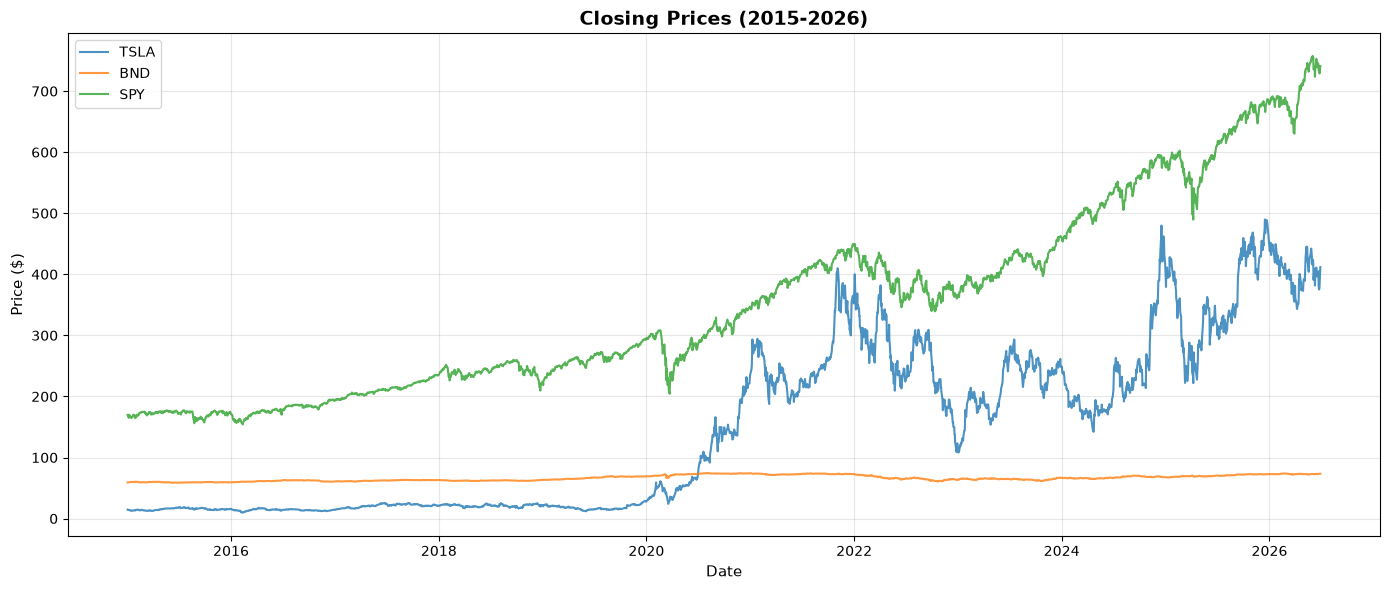

In [11]:
print("\n" + "="*60)
print("CLOSING PRICES OVER TIME")
print("="*60)

plot_prices(prices, title="Closing Prices (2015-2026)")

DAILY RETURNS


DAILY RETURNS


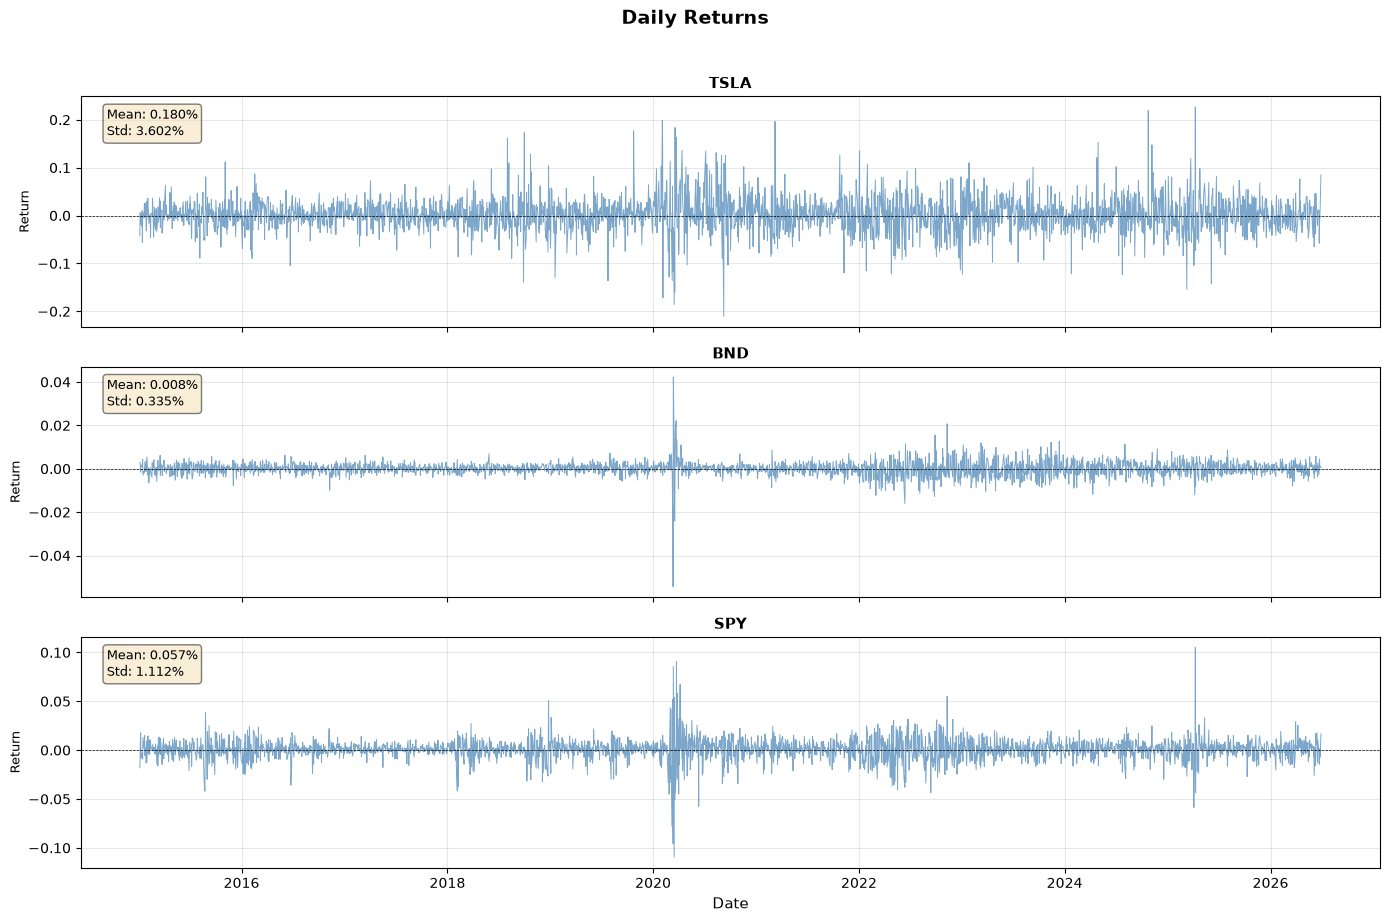

In [12]:
print("\n" + "="*60)
print("DAILY RETURNS")
print("="*60)

plot_returns(returns, title="Daily Returns")


ROLLING VOLATILITY


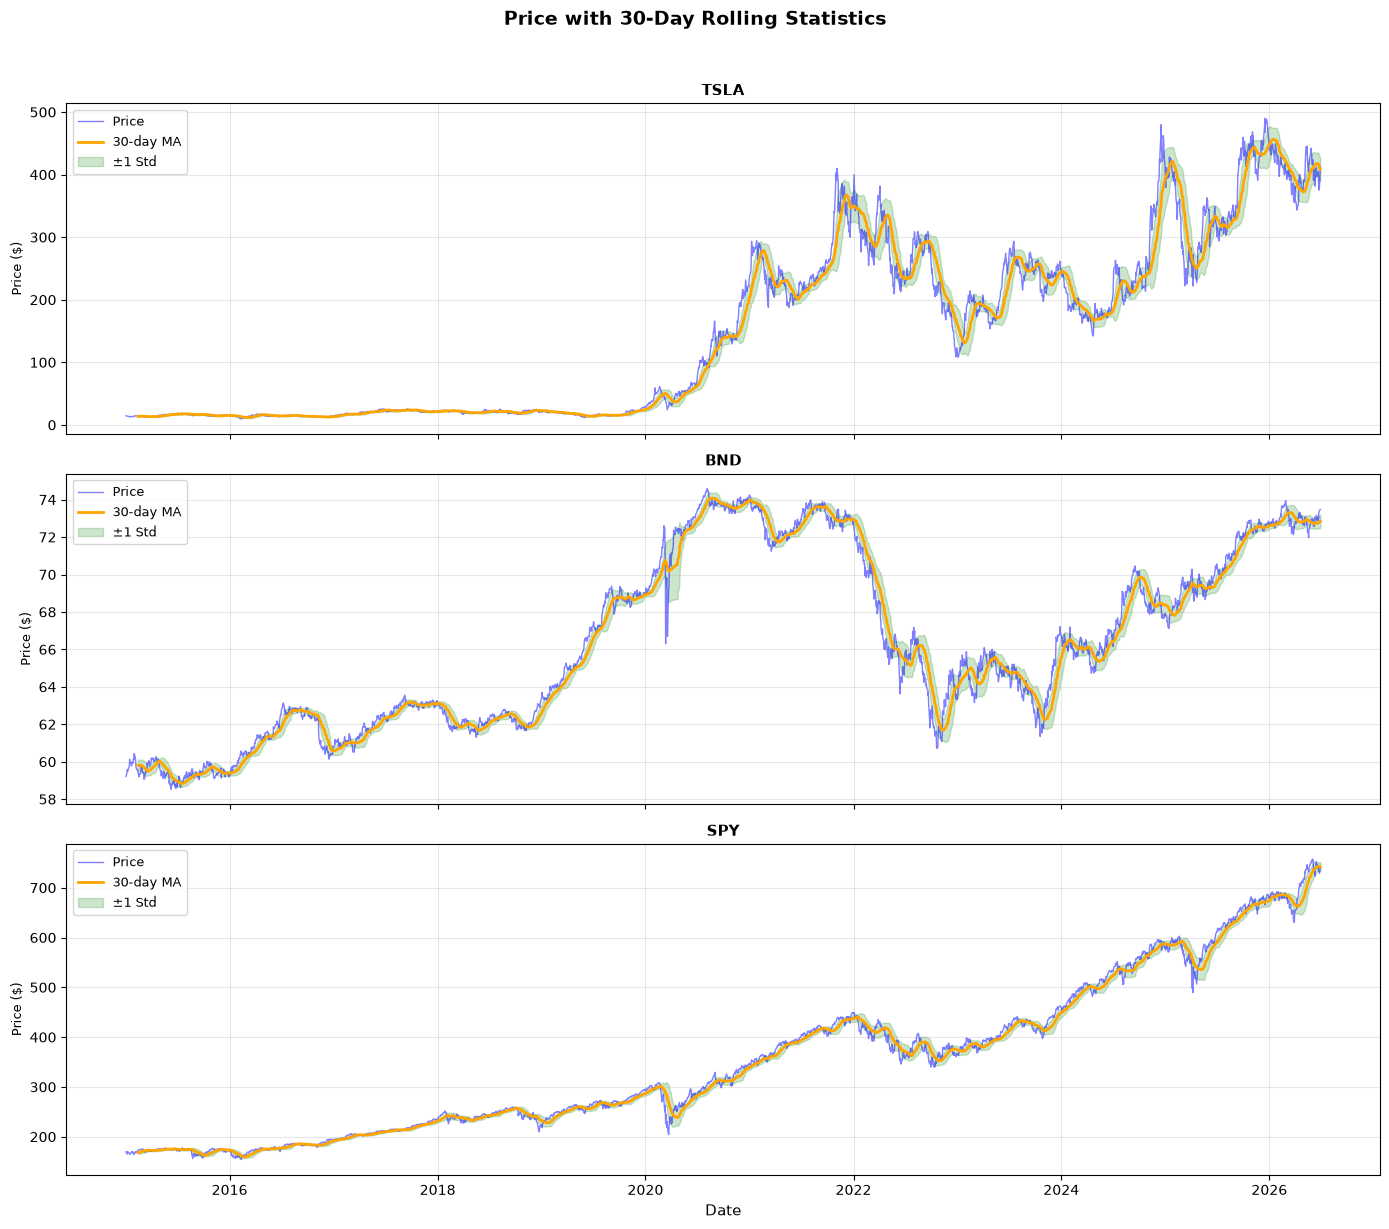

In [13]:
print("\n" + "="*60)
print("ROLLING VOLATILITY")
print("="*60)

plot_rolling_volatility(prices, window=30)


RETURNS DISTRIBUTION


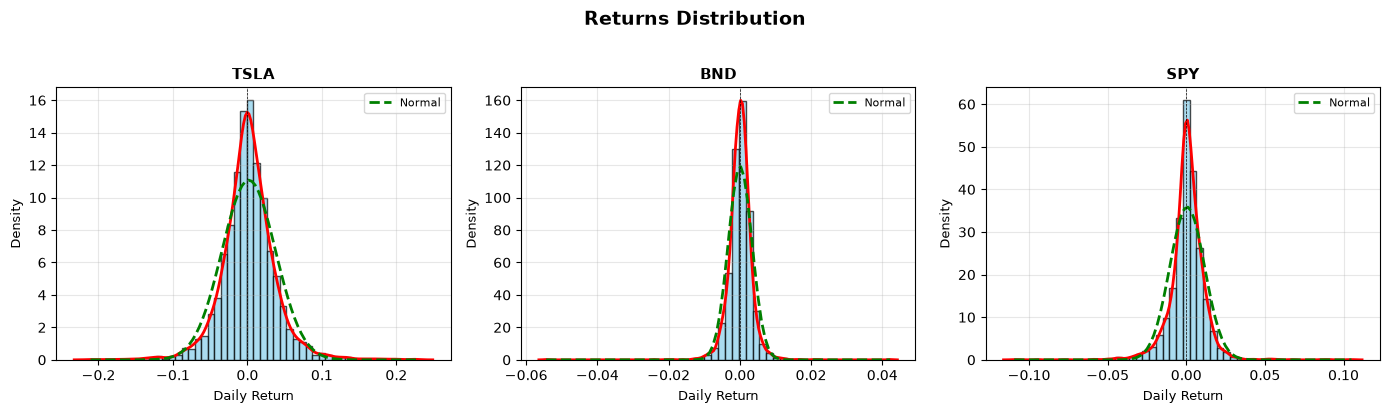

In [14]:
print("\n" + "="*60)
print("RETURNS DISTRIBUTION")
print("="*60)

plot_returns_distribution(returns)


VISUALIZATION 5: CORRELATION HEATMAP


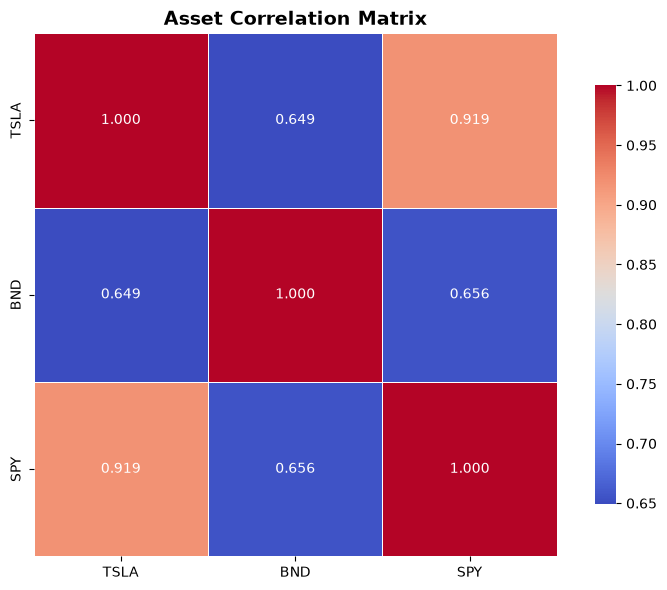

,TSLA,BND,SPY
TSLA,1.0000,0.6493,0.9190
BND,0.6493,1.0000,0.6560
SPY,0.9190,0.6560,1.0000


In [15]:
# ============================================
# CORRELATION HEATMAP
# ============================================

print("\n" + "="*60)
print("VISUALIZATION 5: CORRELATION HEATMAP")
print("="*60)

plot_correlation_heatmap(prices)

### OUTLIER DETECTION

In [17]:
# ============================================
#  OUTLIER DETECTION
# ============================================

print("\n" + "="*60)
print("OUTLIER DETECTION")
print("="*60)

# 10.1 Detect outliers using Z-score method
outliers_dict = detect_all_outliers(returns, threshold=3)

for ticker, outliers in outliers_dict.items():
    print(f"\n {ticker}: {len(outliers)} outliers detected")
    if len(outliers) > 0:
        print(f"  Percentage of days: {len(outliers)/len(returns)*100:.2f}%")
        print(f"  Top 5 most extreme days:")
        for date, val in outliers.head(5).items():
            print(f"    {date.date()}: {val*100:.2f}%")




OUTLIER DETECTION

 TSLA: 46 outliers detected
  Percentage of days: 1.59%
  Top 5 most extreme days:
    2015-11-04: 11.17%
    2018-08-02: 16.19%
    2018-08-07: 10.99%
    2018-09-28: -13.90%
    2018-10-01: 17.35%

 BND: 33 outliers detected
  Percentage of days: 1.14%
  Top 5 most extreme days:
    2020-03-10: -1.34%
    2020-03-11: -1.89%
    2020-03-12: -5.44%
    2020-03-13: 4.22%
    2020-03-16: 1.05%

 SPY: 39 outliers detected
  Percentage of days: 1.35%
  Top 5 most extreme days:
    2015-08-24: -4.21%
    2015-08-26: 3.84%
    2016-06-24: -3.59%
    2018-02-05: -4.18%
    2018-02-08: -3.75%


In [18]:
#  Analyze extreme days in detail
extreme_days = analyze_extreme_days(returns, top_n=5, threshold=3)


EXTREME DAYS ANALYSIS

 TSLA - Top 5 Extreme Days:
----------------------------------------
  2025-04-09: 📈 UP 22.69%
    Very extreme (>5%)
  2024-10-24: 📈 UP 21.92%
    Very extreme (>5%)
  2020-09-08: 📉 DOWN -21.06%
    Very extreme (>5%)
  2020-02-03: 📈 UP 19.89%
    Very extreme (>5%)
  2021-03-09: 📈 UP 19.64%
    Very extreme (>5%)

 BND - Top 5 Extreme Days:
----------------------------------------
  2020-03-12: 📉 DOWN -5.44%
    Very extreme (>5%)
  2020-03-13: 📈 UP 4.22%
     Extreme (>3%)
  2020-03-18: 📉 DOWN -2.41%
  2020-03-23: 📈 UP 2.21%
  2022-11-10: 📈 UP 2.07%

 SPY - Top 5 Extreme Days:
----------------------------------------
  2020-03-16: 📉 DOWN -10.94%
    Very extreme (>5%)
  2025-04-09: 📈 UP 10.50%
    Very extreme (>5%)
  2020-03-12: 📉 DOWN -9.57%
    Very extreme (>5%)
  2020-03-24: 📈 UP 9.06%
    Very extreme (>5%)
  2020-03-13: 📈 UP 8.55%
    Very extreme (>5%)


#### STATIONARITY TESTS

In [20]:
# Run all stationarity tests
stationarity_results = analyze_all_stationarity(prices, returns)

# Create summary table for easy viewing
print("\n Stationarity Summary Table:")
summary_df = []
for key, result in stationarity_results.items():
    summary_df.append({
        'Series': result['name'],
        'ADF Statistic': f"{result['statistic']:.4f}",
        'p-value': f"{result['p_value']:.4f}",
        'Stationary': ' Yes' if result['is_stationary'] else ' No'
    })
display(pd.DataFrame(summary_df))


STATIONARITY ANALYSIS

 Testing CLOSING PRICES (should be non-stationary):

ADF Test - TSLA (Price)
----------------------------------------
  ADF Statistic: -1.069599
  p-value: 0.727042
   NON-STATIONARY
  Critical values:
    1%: -3.432639
    5%: -2.862551
    10%: -2.567308

ADF Test - BND (Price)
----------------------------------------
  ADF Statistic: -1.047870
  p-value: 0.735407
   NON-STATIONARY
  Critical values:
    1%: -3.432627
    5%: -2.862546
    10%: -2.567306

ADF Test - SPY (Price)
----------------------------------------
  ADF Statistic: 1.308944
  p-value: 0.996659
   NON-STATIONARY
  Critical values:
    1%: -3.432624
    5%: -2.862545
    10%: -2.567305

 Testing RETURNS (should be stationary):

ADF Test - TSLA (Returns)
----------------------------------------
  ADF Statistic: -53.971893
  p-value: 0.000000
  STATIONARY
  Critical values:
    1%: -3.432618
    5%: -2.862542
    10%: -2.567303

ADF Test - BND (Returns)
----------------------------------------


,Series,ADF Statistic,p-value,Stationary
0,TSLA (Price),-1.0696,0.7270,No
1,BND (Price),-1.0479,0.7354,No
2,SPY (Price),1.3089,0.9967,No
3,TSLA (Returns),-53.9719,0.0000,Yes
4,BND (Returns),-15.2212,0.0000,Yes
5,SPY (Returns),-17.5722,0.0000,Yes


### RISK METRICS

In [21]:
# Calculate risk metrics for all assets
risk_metrics = calculate_all_risk_metrics(returns, confidence=0.95)

# Display results
for ticker, metrics in risk_metrics.items():
    print(f"\n {ticker}:")
    print("-" * 40)
    for key, value in metrics.items():
        if key == 'confidence_level':
            continue  # Skip this internal key
        elif 'Ratio' in key or 'Skewness' in key or 'Kurtosis' in key:
            print(f"  {key:20}: {value:.4f}")
        else:
            print(f"  {key:20}: {value:.2f}%")


 TSLA:
----------------------------------------
  Daily Mean (%)      : 0.18%
  Daily Std (%)       : 3.60%
  Annual Return (%)   : 45.42%
  Annual Volatility (%): 57.18%
  VaR (95%)           : -5.17%
  CVaR (%)            : -7.86%
  Sharpe Ratio        : 0.7944
  Max Drawdown (%)    : -73.63%
  Skewness            : 0.2934
  Kurtosis            : 4.4670

 BND:
----------------------------------------
  Daily Mean (%)      : 0.01%
  Daily Std (%)       : 0.33%
  Annual Return (%)   : 2.03%
  Annual Volatility (%): 5.31%
  VaR (95%)           : -0.48%
  CVaR (%)            : -0.74%
  Sharpe Ratio        : 0.3812
  Max Drawdown (%)    : -18.58%
  Skewness            : -0.9183
  Kurtosis            : 36.5297

 SPY:
----------------------------------------
  Daily Mean (%)      : 0.06%
  Daily Std (%)       : 1.11%
  Annual Return (%)   : 14.43%
  Annual Volatility (%): 17.65%
  VaR (95%)           : -1.67%
  CVaR (%)            : -2.68%
  Sharpe Ratio        : 0.8175
  Max Drawdown (%) 

In [23]:
generate_summary_report(prices, returns, risk_metrics, stationarity_results)


EDA SUMMARY REPORT

PRICE TRENDS:
  TSLA: 🟢 UP +2716.8% ($14.62 → $411.84)
  BND: 🟢 UP +24.1% ($59.21 → $73.47)
  SPY: 🟢 UP +336.7% ($169.69 → $741.00)

VOLATILITY (Daily):
  TSLA: ±3.60%
  BND: ±0.33%
  SPY: ±1.11%

RISK METRICS:
  TSLA:
    VaR (95%): -5.17% daily loss
    Sharpe: 0.794
    Max Drawdown: -73.63%
  BND:
    VaR (95%): -0.48% daily loss
    Sharpe: 0.381
    Max Drawdown: -18.58%
  SPY:
    VaR (95%): -1.67% daily loss
    Sharpe: 0.817
    Max Drawdown: -33.72%

CORRELATION:
  TSLA ↔ BND: 0.649
  TSLA ↔ SPY: 0.919
  BND ↔ SPY: 0.656

 STATIONARITY:
  TSLA: Price ❌ | Returns ✅
  BND: Price ❌ | Returns ✅
  SPY: Price ❌ | Returns ✅


In [25]:
os.makedirs('../data/processed', exist_ok=True)
# Save combined closing prices for all assets
prices.to_csv('../data/processed/prices.csv')
print(" Saved: ../ data/processed/prices.csv")

# Save daily returns for all assets
returns.to_csv('../data/processed/returns.csv')
print(" Saved: ../ data/processed/returns.csv")

# Save each asset's cleaned data separately
for ticker in TICKERS:
    cleaned_data[ticker].to_csv(f'../data/processed/{ticker}_cleaned.csv')
    print(f" Saved: ../data/processed/{ticker}_cleaned.csv")

 Saved: ../ data/processed/prices.csv
 Saved: ../ data/processed/returns.csv
 Saved: ../data/processed/TSLA_cleaned.csv
 Saved: ../data/processed/BND_cleaned.csv
 Saved: ../data/processed/SPY_cleaned.csv


## Data Preprocessing & EDA Findings

###  Project Overview
- **Period**: January 2015 - June 2026 (11.5 years)
- **Assets**: TSLA (Tesla), BND (Bond ETF), SPY (S&P 500 ETF)
- **Data Points**: 2,888 daily observations per asset
- **Data Quality**: Complete, no missing values after cleaning

---

###  Key Findings

#### 1. Performance & Risk Profile

| Asset | Total Return | Daily Volatility | Max Drawdown | Sharpe Ratio |
|-------|--------------|------------------|--------------|--------------|
| **TSLA** | **+2,716%** ($14.62 → $411.84) | ±3.60% | -73.63% | 0.794 |
| **SPY** | **+337%** ($169.69 → $741.00) | ±1.11% | -33.72% | 0.818 |
| **BND** | **+24%** ($59.21 → $73.47) | ±0.33% | -18.58% | 0.381 |

**Interpretation**:
- **TSLA**: Exceptional growth but extreme risk - investors could have lost 74% at the worst point
- **SPY**: Best risk-adjusted returns (highest Sharpe Ratio) - efficient market exposure
- **BND**: Safest option with lowest volatility and drawdown, but modest returns

#### 2. Correlation Structure (Diversification Analysis)

| Asset Pair | Correlation | Strength |
|------------|-------------|----------|
| TSLA ↔ SPY | **0.919** | Very Strong |
| BND ↔ SPY | **0.656** | Moderate |
| TSLA ↔ BND | **0.649** | Moderate |

**Interpretation**:
- TSLA and SPY move almost identically → **Poor diversification** together
- BND offers **moderate diversification** against both TSLA and SPY
- Adding BND to a portfolio of stocks reduces overall risk

#### 3. Stationarity Test Results (ADF Test)

| Asset | Prices (p-value) | Returns (p-value) | Status |
|-------|------------------|-------------------|--------|
| TSLA | 0.7270 | 0.0000 |  Prices Non-Stationary |  Returns Stationary |
| BND | 0.7354 | 0.0000 | Prices Non-Stationary |  Returns Stationary |
| SPY | 0.9967 | 0.0000 |  Prices Non-Stationary |  Returns Stationary |

**Interpretation**:
- **Prices are NON-STATIONARY** → Statistical properties change over time → Need differencing (d=1) for ARIMA
- **Returns are STATIONARY** → Statistical properties are stable → Ready for modeling without transformation

#### 4. Risk Metrics Summary (95% Confidence)

| Metric | TSLA | BND | SPY |
|--------|------|-----|-----|
| **Value at Risk (VaR)** | -5.17% daily | -0.48% daily | -1.67% daily |
| **Expected Shortfall (CVaR)** | -7.86% | -0.74% | -2.68% |
| **Max Drawdown** | -73.63% | -18.58% | -33.72% |
| **Sharpe Ratio** | 0.794 | 0.381 | 0.818 |

**Interpretation**:
- SPY offers the **best risk-adjusted returns** (highest Sharpe)
- TSLA's Sharpe is decent but **drawdowns are severe** - 74% potential loss
- BND is the **safest** but provides modest returns

#### 5. Outlier Detection (Z-Score > 3)

| Asset | Outliers | Percentage | Most Extreme Day |
|-------|----------|------------|------------------|
| **TSLA** | 46 | 1.59% | +22.69% (Apr 9, 2025) |
| **SPY** | 39 | 1.35% | -10.94% (Mar 16, 2020) |
| **BND** | 33 | 1.14% | -5.44% (Mar 12, 2020) |

**Interpretation**:
- Extreme days cluster around **major market events** (COVID-19 pandemic)
- TSLA has more frequent and larger extremes → **higher tail risk**
- These outliers impact model accuracy and risk calculations

#### 6. Returns Distribution Analysis

| Asset | Skewness | Kurtosis | Distribution Type |
|-------|----------|----------|-------------------|
| TSLA | **+0.293** | **4.467** | Positive skew, fat tails |
| BND | **-0.918** | **36.530** | Negative skew, extreme tails |
| SPY | **-0.308** | **14.025** | Negative skew, fat tails |

**Interpretation**:
- Returns are **NOT normally distributed** → Normal models underestimate extreme events
- **Fat tails** → Extreme events occur more frequently than expected
- TSLA has **more big up days** (positive skew)
- SPY and BND have **more big down days** (negative skew)

---

### Visualizations Summary

###Closing Prices Over Time
- Shows **exponential growth** pattern, especially for TSLA
- **Volatility clusters** during crisis periods (2020, 2022, 2025)
- BND remains **relatively flat** throughout

#### Daily Returns
- TSLA shows **extreme volatility** with large daily swings
- SPY shows **moderate volatility** with crisis-driven spikes
- BND shows **minimal volatility** - most predictable

#### Rolling Volatility (30-day)
- TSLA's volatility **increases with price** → wider bands over time
- SPY's volatility **spikes during crises** but returns to normal
- BND's volatility **remains consistently low**

#### Returns Distribution
- All assets show **fat tails** (more extremes than normal)
- TSLA shows **positive skew** (more big up days)
- SPY and BND show **negative skew** (more big down days)

#### Correlation Heatmap
- TSLA-SPY: **Very strong correlation** (0.919)
- BND-Stocks: **Moderate correlation** (0.65)
- **BND provides diversification benefits**

---